# BC FIRMS detections
Run cells in order using the Python environment installed from `requirements.txt`.
Based on the four NASA notebooks in `learning-docs/`: API use, ingest, visualization, and polygon subsetting.
[Area API](https://firms.modaps.eosdis.nasa.gov/api/area/) ? [Availability](https://firms.modaps.eosdis.nasa.gov/api/data_availability/).
Satellite detections are observations, not individual fires. These data will initialize later game scenarios.

## 1. Config

In [ ]:
# Defaults; papermill overrides these (see run_firms.py).
YEAR = 2023
START = "2023-05-01"
END = "2023-10-31"

In [ ]:
from pathlib import Path
from datetime import date, timedelta
from io import StringIO
import os
import sys
import time
import calendar
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from dotenv import load_dotenv
from IPython.display import display

SOURCE = "VIIRS_SNPP_SP"
CHUNK_DAYS = 5
USE_SAMPLE = False

# Jupyter normally starts in the notebook folder; also support repo-root launch.
NOTEBOOK_FOLDER = Path.cwd().resolve()
REPO_ROOT = next((p for p in (NOTEBOOK_FOLDER, *NOTEBOOK_FOLDER.parents)
                  if (p / "CLAUDE.md").is_file()), None)
if REPO_ROOT is None:
    raise RuntimeError("Launch this notebook from the repository root or its data folder.")
# Support imports when the kernel starts in either data/ or the repo root.
sys.path.insert(0, str(REPO_ROOT / "notebooks"))
from bc_geo import BC_BBOX, load_bc_boundary
# YEAR, START and END come from the parameters cell above; papermill passes dates as strings.
START, END = (date.fromisoformat(str(day)) for day in (START, END))

load_dotenv(REPO_ROOT / ".env", override=False)
MAP_KEY = os.getenv("FIRMS_MAP_KEY", "").strip()
if not USE_SAMPLE and not MAP_KEY:
    raise RuntimeError("Set FIRMS_MAP_KEY in the repo-root .env, or set USE_SAMPLE = True.")
if not 1 <= CHUNK_DAYS <= 5:
    raise ValueError("FIRMS CHUNK_DAYS must be between 1 and 5.")

RAW_DIR = REPO_ROOT / "data" / "raw" / "firms"
CACHE_DIR = RAW_DIR / "cache"
PROCESSED_DIR = REPO_ROOT / "data" / "processed" / "firms"
for folder in (RAW_DIR, CACHE_DIR, PROCESSED_DIR):
    folder.mkdir(parents=True, exist_ok=True)
BASE_URL = "https://firms.modaps.eosdis.nasa.gov"
SAMPLE_URL = BASE_URL + "/content/notebooks/sample_viirs_snpp_071223.csv"
# Sample is July 12, 2023, not a substitute for the full fire season.
OUTPUT_TAG = f"{YEAR}_sample" if USE_SAMPLE else str(YEAR)
SESSION = requests.Session()


def redact(text):
    return str(text).replace(MAP_KEY, "[REDACTED]") if MAP_KEY else str(text)


def fetch(url, *, params=None, expected_prefix=None, attempts=4):
    """Bounded exponential backoff; never expose a key-bearing request URL."""
    for attempt in range(attempts):
        try:
            response = SESSION.get(url, params=params, timeout=(15, 120))
        except requests.RequestException:
            reason = "Network request failed (request URL withheld)."
        else:
            text = response.text.lstrip("\ufeff\r\n ")
            if response.status_code == 200 and (
                expected_prefix is None or text.startswith(expected_prefix)
            ):
                return response
            reason = f"HTTP {response.status_code}: {redact(response.text)}"
        print(reason)
        if attempt + 1 < attempts:
            delay = 2 ** (attempt + 1)
            print(f"Retry {attempt + 2}/{attempts} in {delay}s")
            time.sleep(delay)
    raise RuntimeError(reason) from None


def transaction_count():
    response = fetch(BASE_URL + "/mapserver/mapkey_status/", params={"MAP_KEY": MAP_KEY})
    try:
        status = response.json()
        return int(status["current_transactions"])
    except (ValueError, KeyError, TypeError):
        raise RuntimeError("mapkey_status did not return a valid transaction count: "
                           + redact(response.text)) from None


def read_detections(text):
    if not text.lstrip("\ufeff\r\n ").startswith("latitude"):
        raise RuntimeError("FIRMS returned an error instead of CSV: " + redact(text))
    frame = pd.read_csv(StringIO(text), dtype={"acq_time": "string"})
    required = {"latitude", "longitude", "acq_date", "acq_time", "confidence", "frp", "daynight"}
    missing = required - set(frame.columns)
    if missing:
        raise RuntimeError(f"Missing detection columns: {sorted(missing)}")
    return frame

## 2. Key and coverage check

In [2]:
if USE_SAMPLE:
    print("Sample mode: skipping key and availability checks.")
else:
    print(f"Transactions used: {transaction_count()}")
    response = fetch(f"{BASE_URL}/api/data_availability/csv/{MAP_KEY}/{SOURCE}",
                     expected_prefix="data_id")
    availability = pd.read_csv(StringIO(response.text))
    required = {"data_id", "min_date", "max_date"}
    if not required.issubset(availability.columns):
        raise RuntimeError("Unexpected data_availability schema.")
    coverage = availability[availability["data_id"].str.upper() == SOURCE].copy()
    coverage["min_date"] = pd.to_datetime(coverage["min_date"], utc=True)
    coverage["max_date"] = pd.to_datetime(coverage["max_date"], utc=True)
    # Require full YEAR coverage; this also guarantees the May?October window.
    first = pd.Timestamp(f"{YEAR}-01-01", tz="UTC")
    last = pd.Timestamp(f"{YEAR}-12-31", tz="UTC")
    if not ((coverage["min_date"] <= first) & (coverage["max_date"] >= last)).any():
        raise RuntimeError(f"{SOURCE} does not cover all of {YEAR}. "
                           "Check FIRMS data_availability or use sample mode.")
    display(coverage)

Transactions used: 0


,data_id,min_date,max_date
0,VIIRS_SNPP_SP,2012-01-20 00:00:00+00:00,2026-06-30 00:00:00+00:00


## 3. Download
Chunks include their start date and the next `days - 1` days. Cached chunks are reused.
Counts are NASA's current 10-minute transaction-window counters and can reset during a run.
Sample mode uses NASA's one-day tutorial CSV and skips the authenticated download.

In [3]:
chunks = []
if USE_SAMPLE:
    sample_path = CACHE_DIR / "sample_viirs_snpp_071223.csv"
    if sample_path.exists():
        sample = read_detections(sample_path.read_text(encoding="utf-8"))
    else:
        response = fetch(SAMPLE_URL, expected_prefix="latitude")
        sample = read_detections(response.text)
        sample.to_csv(sample_path, index=False)
    west, south, east, north = map(float, BC_BBOX.split(","))
    chunks.append(sample[sample.longitude.between(west, east)
                         & sample.latitude.between(south, north)].copy())
    print("Loaded NASA tutorial sample (July 12, 2023); August plot may be empty.")
else:
    print(f"Transactions before download: {transaction_count()}")
    try:
        chunk_start = START
        while chunk_start <= END:
            days = min(CHUNK_DAYS, (END - chunk_start).days + 1)
            chunk_end = chunk_start + timedelta(days=days - 1)
            # Include source, bounding box and dates to avoid incompatible cache reuse.
            cache_path = CACHE_DIR / f"{SOURCE}_{BC_BBOX}_{chunk_start}_{chunk_end}.csv"
            if cache_path.exists():
                frame = read_detections(cache_path.read_text(encoding="utf-8"))
                origin = "cache"
            else:
                url = (f"{BASE_URL}/api/area/csv/{MAP_KEY}/{SOURCE}/"
                       f"{BC_BBOX}/{days}/{chunk_start.isoformat()}")
                response = fetch(url, expected_prefix="latitude")
                frame = read_detections(response.text)
                frame.to_csv(cache_path, index=False)
                origin = "download"
            chunks.append(frame)
            print(f"{chunk_start}?{chunk_end}: {len(frame):,} detections ({origin})")
            chunk_start = chunk_end + timedelta(days=1)
    finally:
        print(f"Transactions after download: {transaction_count()}")

Transactions before download: 1


2023-05-01?2023-05-05: 9,174 detections (download)


2023-05-06?2023-05-10: 18,938 detections (download)


2023-05-11?2023-05-15: 23,144 detections (download)


2023-05-16?2023-05-20: 50,778 detections (download)


...

2023-10-08?2023-10-12: 1,098 detections (download)


2023-10-13?2023-10-17: 509 detections (download)


2023-10-18?2023-10-22: 1,060 detections (download)


2023-10-23?2023-10-27: 1,657 detections (download)
2023-10-28?2023-10-31: 885 detections (download)


Transactions after download: 369


In [ ]:
# Fill S-NPP outages from NOAA-20: any run of 5+ consecutive season days with no S-NPP detections.
# Same BC box, chunking and caching as the download above. `source` records the satellite product.
GAP_SOURCE = "VIIRS_NOAA20_SP"
MIN_GAP_DAYS = 5
chunks = [frame.assign(source=SOURCE) for frame in chunks]
if USE_SAMPLE:
    print("Sample mode: skipping gap fill.")
else:
    seen_dates = set(pd.concat(chunks)["acq_date"].astype("string"))
    empty_days = [day.date() for day in pd.date_range(START, END, freq="D")
                  if str(day.date()) not in seen_dates]
    gaps = []  # [first day, last day] for each run of consecutive empty days
    for day in empty_days:
        if gaps and (day - gaps[-1][1]).days == 1:
            gaps[-1][1] = day
        else:
            gaps.append([day, day])
    gaps = [gap for gap in gaps if (gap[1] - gap[0]).days + 1 >= MIN_GAP_DAYS]
    if not gaps:
        print(f"No S-NPP gaps of {MIN_GAP_DAYS}+ days; nothing filled.")
    for gap_start, gap_end in gaps:
        filled = 0
        chunk_start = gap_start
        while chunk_start <= gap_end:
            days = min(CHUNK_DAYS, (gap_end - chunk_start).days + 1)
            chunk_end = chunk_start + timedelta(days=days - 1)
            cache_path = CACHE_DIR / f"{GAP_SOURCE}_{BC_BBOX}_{chunk_start}_{chunk_end}.csv"
            if cache_path.exists():
                frame = read_detections(cache_path.read_text(encoding="utf-8"))
            else:
                url = (f"{BASE_URL}/api/area/csv/{MAP_KEY}/{GAP_SOURCE}/"
                       f"{BC_BBOX}/{days}/{chunk_start.isoformat()}")
                response = fetch(url, expected_prefix="latitude")
                frame = read_detections(response.text)
                frame.to_csv(cache_path, index=False)
            chunks.append(frame.assign(source=GAP_SOURCE))
            filled += len(frame)
            chunk_start = chunk_end + timedelta(days=1)
        print(f"Filled {gap_start} to {gap_end} ({(gap_end - gap_start).days + 1} days) "
              f"from {GAP_SOURCE}: {filled:,} detections")

## 4. Combine and save raw data

In [4]:
combined = pd.concat(chunks, ignore_index=True)
for column in ["latitude", "longitude", "frp", "bright_ti4", "bright_ti5", "scan", "track"]:
    combined[column] = pd.to_numeric(combined[column])
raw = combined.drop_duplicates().reset_index(drop=True)
print(f"Removed {len(combined) - len(raw):,} duplicate rows; {len(raw):,} remain.")
raw_path = RAW_DIR / f"firms_bc_{OUTPUT_TAG}_raw.csv"
raw.to_csv(raw_path, index=False)
print(f"Saved {raw_path.relative_to(REPO_ROOT)}")

Removed 0 duplicate rows; 652,358 remain.


Saved data\raw\firms_bc_2023_raw.csv


## 5. Clean timestamps and confidence

In [5]:
clean = raw.copy()
acq_time = pd.to_numeric(clean["acq_time"], errors="raise").astype("Int64").astype("string").str.zfill(4)
clean["acq_datetime"] = pd.to_datetime(
    clean["acq_date"].astype("string") + " " + acq_time,
    format="%Y-%m-%d %H%M", utc=True, errors="raise"
)
if clean["acq_datetime"].isna().any():
    raise ValueError("Missing acquisition timestamps; inspect raw data before continuing.")
clean["local_time"] = clean["acq_datetime"].dt.tz_convert("America/Vancouver")
clean["confidence"] = clean["confidence"].astype("string").str.strip().str.lower()
before = len(clean)
clean = clean[clean["confidence"].isin(["n", "h"])].copy()
# Keep the requested inclusive UTC calendar window even if upstream returns extra rows.
clean = clean[clean["acq_datetime"].between(
    pd.Timestamp(START, tz="UTC"), pd.Timestamp(END + timedelta(days=1), tz="UTC"),
    inclusive="left")].copy()
print(f"Removed {before - len(clean):,} low/unknown-confidence or out-of-window rows.")

Removed 22,420 low/unknown-confidence or out-of-window rows.


## 6. Clip to British Columbia
Use the free [Natural Earth 1:10m admin-1 boundary](https://www.naturalearthdata.com/downloads/10m-cultural-vectors/10m-admin-1-states-provinces/).
Its generalized coastline can exclude some near-shore detections. Spatial join includes points on the boundary.

In [ ]:
bc = load_bc_boundary()
points = gpd.GeoDataFrame(clean, geometry=gpd.points_from_xy(clean.longitude, clean.latitude),
                          crs="EPSG:4326")
fires = gpd.sjoin(points, bc, how="inner", predicate="intersects").drop(columns="index_right")
fires = fires.sort_values("acq_datetime").reset_index(drop=True)
print(f"BC clipping dropped {len(points) - len(fires):,} points; {len(fires):,} remain.")
if fires.empty:
    print("No detections remain. Plots and output will show an empty dataset.")

## 7. Sanity checks

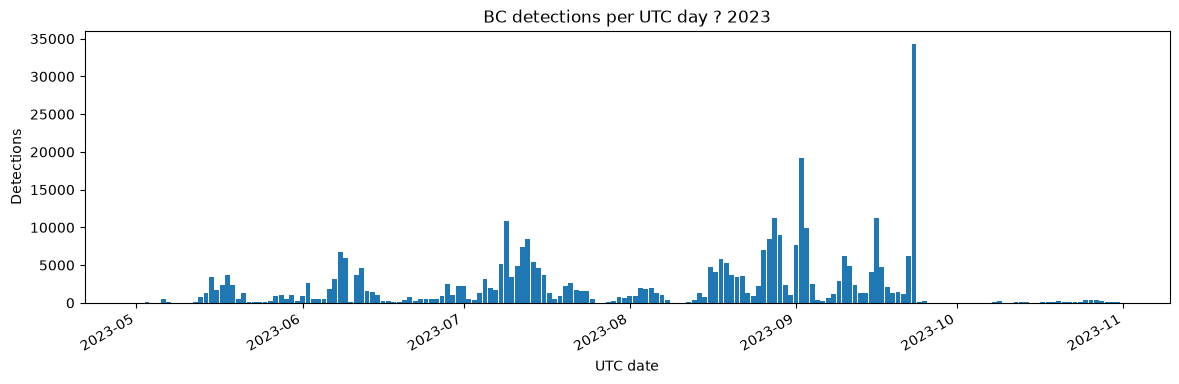

Confidence counts:


confidence
n    346038
h     21216
Name: count, dtype: Int64

FRP (MW):


count    367254.000000
mean         12.477571
std          30.759291
min           0.000000
25%           1.920000
50%           4.010000
75%          10.000000
max        1651.670000
Name: frp, dtype: float64

Day/night counts (D = day, N = night):


daynight
N    248961
D    118293
Name: count, dtype: int64

In [7]:
days = pd.date_range(START, END, freq="D", tz="UTC")
daily = fires.groupby(fires["acq_datetime"].dt.floor("D")).size().reindex(days, fill_value=0)
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily.index, daily.values, width=0.9)
ax.set(title=f"BC detections per UTC day ? {OUTPUT_TAG}", xlabel="UTC date", ylabel="Detections")
fig.autofmt_xdate()
plt.show()
print("Confidence counts:")
display(fires["confidence"].value_counts().reindex(["n", "h"], fill_value=0))
print("FRP (MW):")
display(fires["frp"].describe())
print("Day/night counts (D = day, N = night):")
display(fires["daynight"].value_counts(dropna=False))

## 8. Maps
Months use UTC acquisition dates. For the August 15?20 view, detection age is measured
from the latest detection in that window, following NASA's tutorial. These are observed
hotspots, not simulated fire growth. The map zooms to the detections in that window.

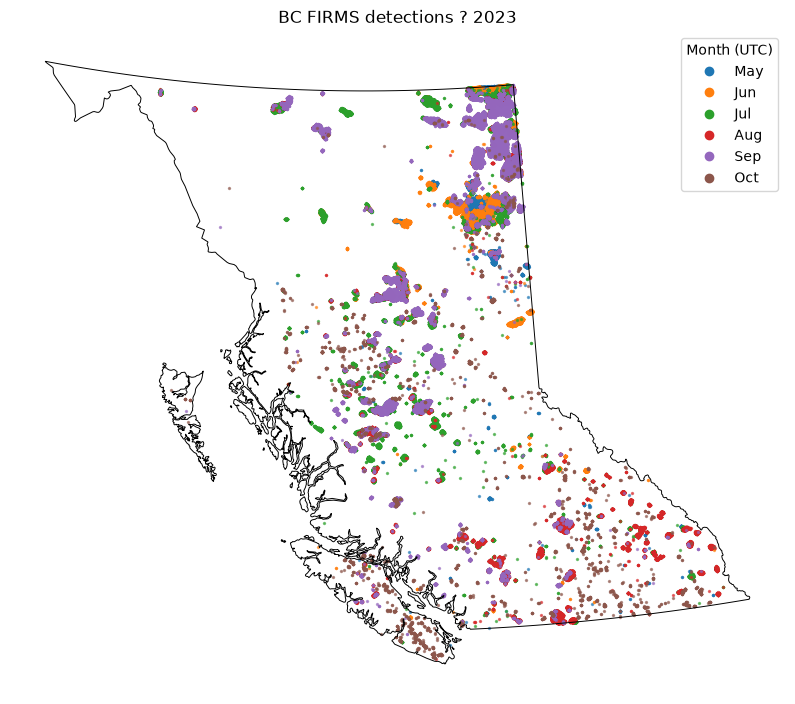

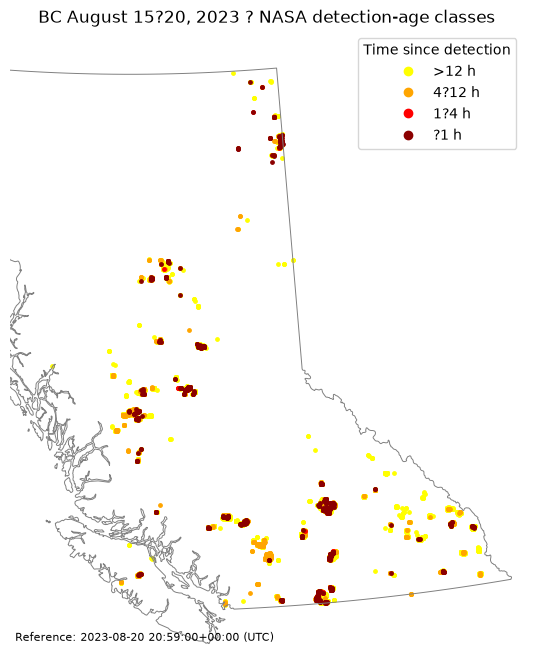

In [8]:
bc_map = bc.to_crs("EPSG:3005")  # BC Albers
fire_map = fires.to_crs(bc_map.crs)
fig, ax = plt.subplots(figsize=(10, 10))
bc_map.boundary.plot(ax=ax, color="black", linewidth=0.7)
month_colors = plt.get_cmap("tab10")
handles = []
for month in range(5, 11):
    subset = fire_map[fire_map["acq_datetime"].dt.month == month]
    color = month_colors(month - 5)
    if not subset.empty:
        subset.plot(ax=ax, color=color, markersize=2, alpha=0.6)
    handles.append(Line2D([], [], marker="o", linestyle="", color=color,
                          label=calendar.month_abbr[month]))
ax.legend(handles=handles, title="Month (UTC)")
ax.set(title=f"BC FIRMS detections ? {OUTPUT_TAG}")
ax.set_axis_off()
plt.show()

zoom_start = pd.Timestamp(f"{YEAR}-08-15", tz="UTC")
zoom_end = pd.Timestamp(f"{YEAR}-08-21", tz="UTC")
zoom = fire_map[fire_map["acq_datetime"].between(zoom_start, zoom_end, inclusive="left")].copy()
fig, ax = plt.subplots(figsize=(10, 8))
bc_map.boundary.plot(ax=ax, color="grey", linewidth=0.7)
if zoom.empty:
    ax.text(0.5, 0.5, "No detections for August 15?20", transform=ax.transAxes, ha="center")
else:
    reference_time = zoom["acq_datetime"].max()
    age = (reference_time - zoom["acq_datetime"]).dt.total_seconds() / 3600
    classes = [(age > 12, "yellow", ">12 h"),
               ((age > 4) & (age <= 12), "orange", "4?12 h"),
               ((age > 1) & (age <= 4), "red", "1?4 h"),
               (age <= 1, "darkred", "?1 h")]
    handles = []
    for mask, color, label in classes:
        subset = zoom[mask]
        if not subset.empty:
            subset.plot(ax=ax, color=color, markersize=6)
        handles.append(Line2D([], [], marker="o", linestyle="", color=color, label=label))
    xmin, ymin, xmax, ymax = zoom.total_bounds
    padding = max(xmax - xmin, ymax - ymin, 20000) * 0.08
    ax.set_xlim(xmin - padding, xmax + padding)
    ax.set_ylim(ymin - padding, ymax + padding)
    ax.legend(handles=handles, title="Time since detection")
    ax.text(0.01, 0.01, f"Reference: {reference_time} (UTC)", transform=ax.transAxes, fontsize=8)
ax.set(title=f"BC August 15?20, {YEAR} ? NASA detection-age classes")
ax.set_axis_off()
plt.show()

## 9. Save processed detections

In [9]:
processed_path = PROCESSED_DIR / f"firms_bc_{OUTPUT_TAG}.csv"
# CSV retains UTC and Vancouver timestamps with offsets, but no geometry column.
fires.drop(columns="geometry").to_csv(processed_path, index=False)
print(f"Saved {len(fires):,} detections to {processed_path.relative_to(REPO_ROOT)}")

Saved 367,254 detections to data\processed\firms_bc_2023.csv
